# Linear Algebra for ML, Deep Learning & Modern AI

Linear algebra is the **language of data and models**. Every time a neural network processes an image, generates text, or makes a recommendation — it is doing linear algebra.

| Section | Concept | Used In |
|---|---|---|
| 1 | Vectors & Vector Operations | Every ML model |
| 2 | Dot Product & Similarity | Embeddings, Attention, Recommendation |
| 3 | Matrices & Matrix Multiplication | Neural network layers |
| 4 | Matrix Transformations | Data preprocessing, PCA |
| 5 | Norms & Regularization | L1/L2, weight decay |
| 6 | Eigenvalues & Eigenvectors | PCA, spectral methods |
| 7 | SVD (Singular Value Decomposition) | Compression, recommender systems |
| 8 | Linear Algebra in Neural Networks | Forward pass, weight matrices |
| 9 | Linear Algebra in Transformers | Attention mechanism, embeddings |
| 10 | Linear Algebra in Generative AI | Latent space, VAE, diffusion |

> **You don't need to memorize formulas.** Focus on the *intuition* — what each operation *means*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## 1. Vectors — The Atoms of Data

A **vector** is just a list of numbers. In ML, every piece of data is a vector.

```
user     = [34, 150, 4.5]      # age, movies_watched, avg_rating
email    = [0.9, 0.1, 0.0]     # word frequencies: "free", "win", "meeting"
image    = [255, 128, 64, ...]  # pixel values
word     = [0.2, -0.5, 0.8, ...] # embedding (learned representation)
```

**Key properties:**
- **Magnitude** (length) — how big is the vector?
- **Direction** — which way does it point?
- Two vectors with the same direction but different magnitudes are *proportional*

User A: [ 34.  150.    4.5]
User B: [ 28.  200.    3.8]
Difference: [-6.  50.  -0.7]
Scaled A: [ 68. 300.   9.]

Magnitude of A: 153.8709
Magnitude of B: 201.9862


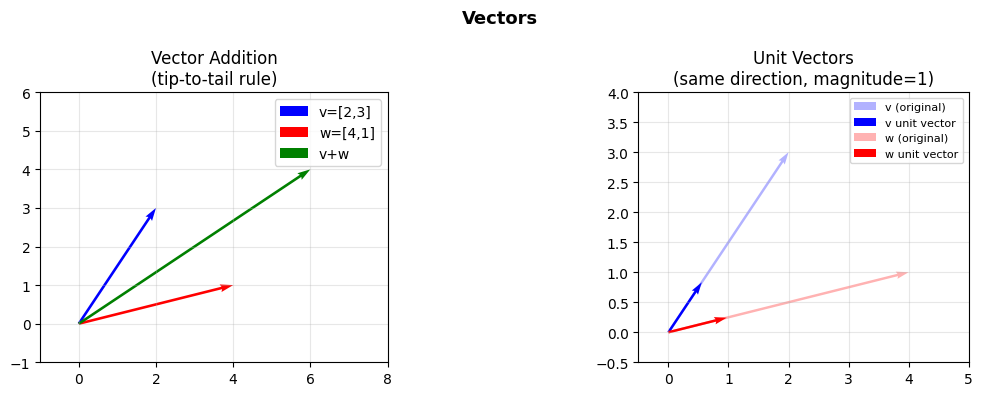

In [2]:
# Vectors in ML
user_a = np.array([34, 150, 4.5])   # user profile
user_b = np.array([28, 200, 3.8])   # another user
weights = np.array([0.1, -0.5, 2.0])  # model weights

# Vector arithmetic
diff = user_b - user_a              # difference between users
scaled = user_a * 2                 # scaling

print("User A:", user_a)
print("User B:", user_b)
print("Difference:", diff)
print("Scaled A:", scaled)

# Magnitude (L2 norm = Euclidean length)
mag_a = np.linalg.norm(user_a)
mag_b = np.linalg.norm(user_b)
print(f"\nMagnitude of A: {mag_a:.4f}")
print(f"Magnitude of B: {mag_b:.4f}")

# Visualize 2D vectors
v = np.array([2, 3])
w = np.array([4, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', label='v=[2,3]')
ax.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='red', label='w=[4,1]')
ax.quiver(0, 0, v[0]+w[0], v[1]+w[1], angles='xy', scale_units='xy', scale=1, color='green', label='v+w')
ax.set_xlim(-1, 8)
ax.set_ylim(-1, 6)
ax.set_title('Vector Addition\n(tip-to-tail rule)')
ax.legend()
ax.set_aspect('equal')

# Unit vector (direction only, magnitude=1)
ax2 = axes[1]
for vec, color, label in [(v, 'blue', 'v'), (w, 'red', 'w')]:
    unit = vec / np.linalg.norm(vec)
    ax2.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
              color=color, alpha=0.3, label=f'{label} (original)')
    ax2.quiver(0, 0, unit[0], unit[1], angles='xy', scale_units='xy', scale=1,
              color=color, label=f'{label} unit vector')
ax2.set_xlim(-0.5, 5)
ax2.set_ylim(-0.5, 4)
ax2.set_title('Unit Vectors\n(same direction, magnitude=1)')
ax2.legend(fontsize=8)
ax2.set_aspect('equal')

plt.suptitle('Vectors', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Dot Product & Cosine Similarity

The **dot product** is the single most important operation in ML.

$$a \cdot b = \sum_i a_i b_i = |a||b|\cos(\theta)$$

- **Positive** → vectors point in similar directions
- **Zero** → vectors are perpendicular (orthogonal) — no relationship
- **Negative** → vectors point in opposite directions

### Why it matters everywhere:
| Use Case | What the dot product computes |
|---|---|
| **Linear regression** | `ŷ = wᵀx` — prediction |
| **Neural net layer** | `z = Wx + b` — activation input |
| **Attention (Transformers)** | `score = Q·Kᵀ` — how much to attend |
| **Embeddings** | `cos_sim(a,b)` — semantic similarity |
| **Recommendation** | `user · item` — preference score |

a: [1 2 3]
b: [4 5 6]
dot(a, b): 32
Manual:    32

=== Word Embedding Similarities ===
cos_sim(king, queen) = 0.8817  ← similar (both royalty)
cos_sim(king, apple) = 0.5310  ← very different


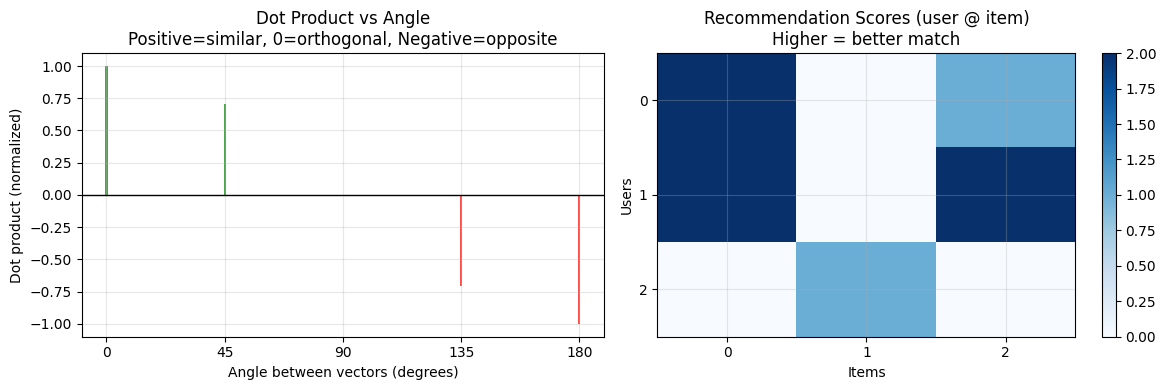

In [3]:
# Dot product
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("a:", a)
print("b:", b)
print("dot(a, b):", np.dot(a, b))     # = 1*4 + 2*5 + 3*6 = 32
print("Manual:   ", sum(a*b))

# Cosine similarity — measures ANGLE between vectors (ignores magnitude)
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Word embedding example (simplified)
# Each word is a vector, similar words should point in similar directions
king   = np.array([0.9, 0.1, 0.8, 0.9])   # royalty, male, power, leadership
queen  = np.array([0.9, 0.9, 0.7, 0.9])   # royalty, female, power, leadership
apple  = np.array([0.0, 0.0, 0.1, 0.0])   # fruit

print("\n=== Word Embedding Similarities ===")
print(f"cos_sim(king, queen) = {cosine_similarity(king, queen):.4f}  ← similar (both royalty)")
print(f"cos_sim(king, apple) = {cosine_similarity(king, apple):.4f}  ← very different")

# Visualize dot product as projection
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Angle between vectors
angles = [0, 45, 90, 135, 180]
dot_products = [np.cos(np.radians(a)) for a in angles]
axes[0].bar(angles, dot_products, color=['green' if d > 0 else 'red' for d in dot_products], alpha=0.7)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_xlabel('Angle between vectors (degrees)')
axes[0].set_ylabel('Dot product (normalized)')
axes[0].set_title('Dot Product vs Angle\nPositive=similar, 0=orthogonal, Negative=opposite')
axes[0].set_xticks(angles)

# Recommendation system example
users = np.array([[1,0,1,0], [1,1,1,0], [0,0,0,1]])  # user preferences
items = np.array([[1,0,1,0], [0,0,0,1], [1,1,0,0]])  # item features
scores = users @ items.T  # dot product = preference scores
im = axes[1].imshow(scores, cmap='Blues', aspect='auto')
axes[1].set_title('Recommendation Scores (user @ item)\nHigher = better match')
axes[1].set_xlabel('Items')
axes[1].set_ylabel('Users')
axes[1].set_xticks([0,1,2])
axes[1].set_yticks([0,1,2])
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

---
## 3. Matrices & Matrix Multiplication

A **matrix** is a 2D grid of numbers.  
A **neural network layer** is a matrix multiplication:

```
input:  x  shape (n_features,)
weight: W  shape (n_outputs, n_features)
output: z = W @ x  shape (n_outputs,)
```

**Intuition for matrix multiplication:**  
Each row of W is a weight vector. Each output neuron computes a *dot product* between its weights and the input.  
So a layer with 512 neurons = 512 simultaneous dot products.

In [4]:
# Matrix multiplication = multiple dot products at once
W = np.array([[0.1, 0.2, 0.3],   # weights for neuron 1
              [0.4, 0.5, 0.6],   # weights for neuron 2
              [0.7, 0.8, 0.9],   # weights for neuron 3
              [1.0, 0.0, 0.5]])  # weights for neuron 4

x = np.array([1.0, 2.0, 3.0])   # input vector

z = W @ x   # matrix-vector multiplication
print("Input x:", x)
print("Weight matrix W shape:", W.shape)
print("Output z = W @ x:", z.round(4))
print("Meaning: 4 neurons each computed a dot product with the same input")

# Batch processing — process many inputs at once (this is how GPUs work)
X_batch = np.random.randn(32, 3)   # 32 samples, 3 features each
Z_batch = X_batch @ W.T            # output: (32, 4) — 32 samples, 4 neurons each

print(f"\nBatch input shape:  {X_batch.shape}  (32 samples × 3 features)")
print(f"Weight matrix shape: {W.shape}  (4 neurons × 3 features)")
print(f"Batch output shape:  {Z_batch.shape}  (32 samples × 4 neuron outputs)")

# Key matrix properties
A = np.array([[1,2],[3,4]])
B = np.array([[5,6],[7,8]])
print("\n=== Key Properties ===")
print("A @ B != B @ A (matrix mult is NOT commutative):")
print("A @ B =", (A @ B).flatten())
print("B @ A =", (B @ A).flatten())

# Transpose
print("\nTranspose flips rows ↔ columns:")
print("A =", A)
print("A.T =", A.T)

Input x: [1. 2. 3.]
Weight matrix W shape: (4, 3)
Output z = W @ x: [1.4 3.2 5.  2.5]
Meaning: 4 neurons each computed a dot product with the same input

Batch input shape:  (32, 3)  (32 samples × 3 features)
Weight matrix shape: (4, 3)  (4 neurons × 3 features)
Batch output shape:  (32, 4)  (32 samples × 4 neuron outputs)

=== Key Properties ===
A @ B != B @ A (matrix mult is NOT commutative):
A @ B = [19 22 43 50]
B @ A = [23 34 31 46]

Transpose flips rows ↔ columns:
A = [[1 2]
 [3 4]]
A.T = [[1 3]
 [2 4]]


---
## 4. Matrix Transformations

Matrices can **transform** data — rotate, scale, stretch, or project it.  
This is what happens to data as it flows through neural network layers.

Think of each layer as applying a transformation that reshapes the data  
into a form where the pattern becomes easier to find.

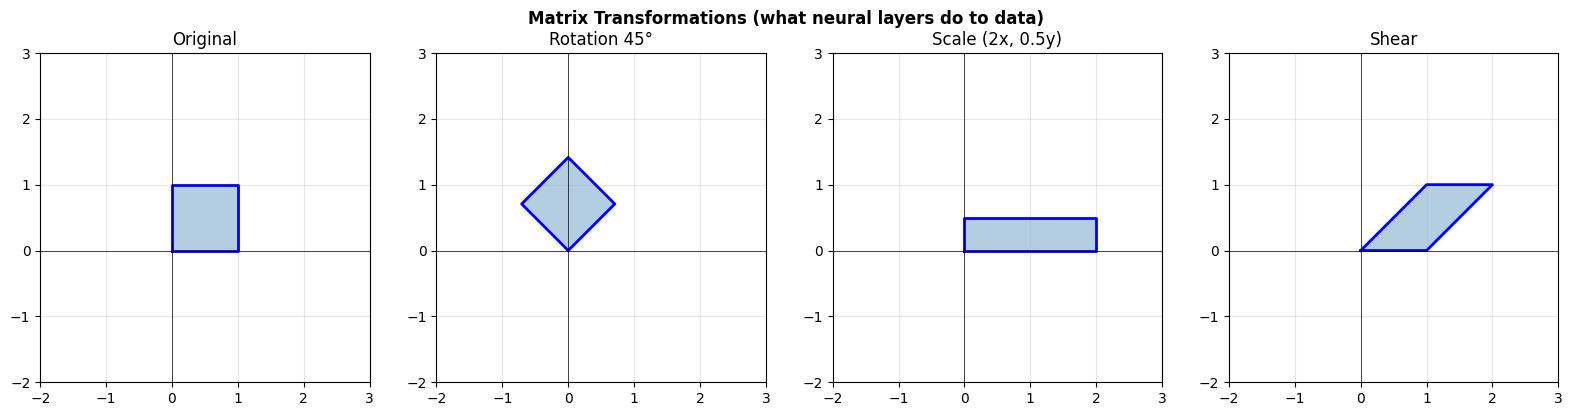

Each layer in a neural network applies a transformation like these.
Deep networks stack many transformations to learn complex patterns.


In [5]:
# Different transformation matrices have different effects
theta = np.pi / 4  # 45 degrees

# Rotation matrix
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Scaling matrix
S = np.array([[2, 0],
              [0, 0.5]])

# Shear matrix
Sh = np.array([[1, 1],
              [0, 1]])

# Create a simple shape (unit square)
square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
transforms = [
    (np.eye(2), 'Original'),
    (R, 'Rotation 45°'),
    (S, 'Scale (2x, 0.5y)'),
    (Sh, 'Shear'),
]
for ax, (T, title) in zip(axes, transforms):
    transformed = T @ square
    ax.fill(transformed[0], transformed[1], alpha=0.4, color='steelblue')
    ax.plot(transformed[0], transformed[1], 'b-', lw=2)
    ax.set_xlim(-2, 3)
    ax.set_ylim(-2, 3)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)

plt.suptitle('Matrix Transformations (what neural layers do to data)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each layer in a neural network applies a transformation like these.")
print("Deep networks stack many transformations to learn complex patterns.")

---
## 5. Norms & Regularization

A **norm** measures the size/length of a vector.

| Norm | Formula | In ML |
|---|---|---|
| **L1 norm** | `|w₁| + |w₂| + ...` | Lasso regression, sparse features |
| **L2 norm** | `√(w₁² + w₂² + ...)` | Ridge regression, weight decay in deep learning |
| **Frobenius** | `√(Σ wᵢⱼ²)` | Matrix regularization |

**Why regularization?**  
Without it, a model can memorize training data (overfitting) by making weights very large.  
Adding `λ||w||` to the loss *penalizes* large weights → forces the model to stay simple.

Weights: [ 3. -4.  1. -2.]
L1 norm (Manhattan): 10.0
L2 norm (Euclidean): 5.4772
L2 norm squared:     30.0


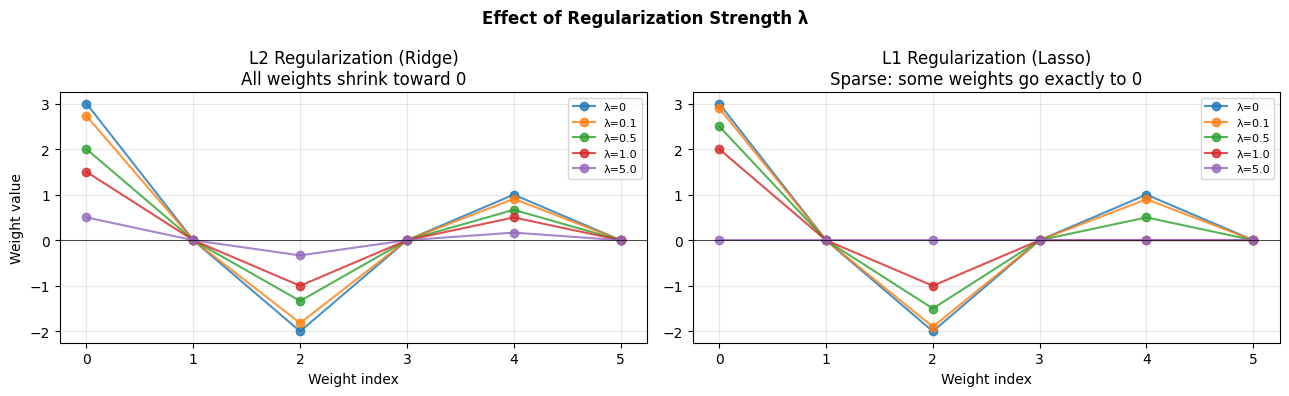


Key difference:
L2 (Ridge): shrinks all weights proportionally — keeps all features
L1 (Lasso): zeros out unimportant weights — automatic feature selection


In [6]:
w = np.array([3.0, -4.0, 1.0, -2.0])

l1 = np.sum(np.abs(w))
l2 = np.linalg.norm(w)
l2_sq = np.sum(w**2)

print("Weights:", w)
print(f"L1 norm (Manhattan): {l1}")
print(f"L2 norm (Euclidean): {l2:.4f}")
print(f"L2 norm squared:     {l2_sq}")

# Effect of regularization on weights
np.random.seed(0)
true_weights = np.array([3.0, 0.0, -2.0, 0.0, 1.0, 0.0])  # 3 of 6 features matter

# Simulate weights learned with different regularization strengths
lambdas = [0, 0.1, 0.5, 1.0, 5.0]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# L2 (Ridge) — shrinks all weights
l2_weights = np.array([true_weights / (1 + lam) for lam in lambdas])
for i, (lam, w_) in enumerate(zip(lambdas, l2_weights)):
    axes[0].plot(range(6), w_, 'o-', label=f'λ={lam}', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_title('L2 Regularization (Ridge)\nAll weights shrink toward 0')
axes[0].set_xlabel('Weight index')
axes[0].set_ylabel('Weight value')
axes[0].legend(fontsize=8)

# L1 (Lasso) — drives some weights exactly to zero
# Simplified: soft threshold
def soft_threshold(w, lam):
    return np.sign(w) * np.maximum(np.abs(w) - lam, 0)

l1_weights = np.array([soft_threshold(true_weights, lam) for lam in lambdas])
for i, (lam, w_) in enumerate(zip(lambdas, l1_weights)):
    axes[1].plot(range(6), w_, 'o-', label=f'λ={lam}', alpha=0.8)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('L1 Regularization (Lasso)\nSparse: some weights go exactly to 0')
axes[1].set_xlabel('Weight index')
axes[1].legend(fontsize=8)

plt.suptitle('Effect of Regularization Strength λ', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey difference:")
print("L2 (Ridge): shrinks all weights proportionally — keeps all features")
print("L1 (Lasso): zeros out unimportant weights — automatic feature selection")

---
## 6. Eigenvalues & Eigenvectors

For a matrix A, an **eigenvector** v is a special direction that doesn't change when A is applied — it only gets *scaled*:

$$A \mathbf{v} = \lambda \mathbf{v}$$

- `v` = eigenvector (the direction)
- `λ` (lambda) = eigenvalue (how much it gets stretched/shrunk)

**In ML:**  
- PCA → eigenvectors of the covariance matrix = directions of maximum variance
- Graph neural networks → eigenvalues of the graph Laplacian
- Stability analysis → largest eigenvalue of the weight matrix

Matrix A:
[[3 1]
 [1 3]]

Eigenvalues:  [4. 2.]
Eigenvectors:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Eigenvector 1: [0.7071 0.7071]
  A @ v  = [2.8284 2.8284]
  λ * v  = [2.8284 2.8284]
  Match: True

Eigenvector 2: [-0.7071  0.7071]
  A @ v  = [-1.4142  1.4142]
  λ * v  = [-1.4142  1.4142]
  Match: True


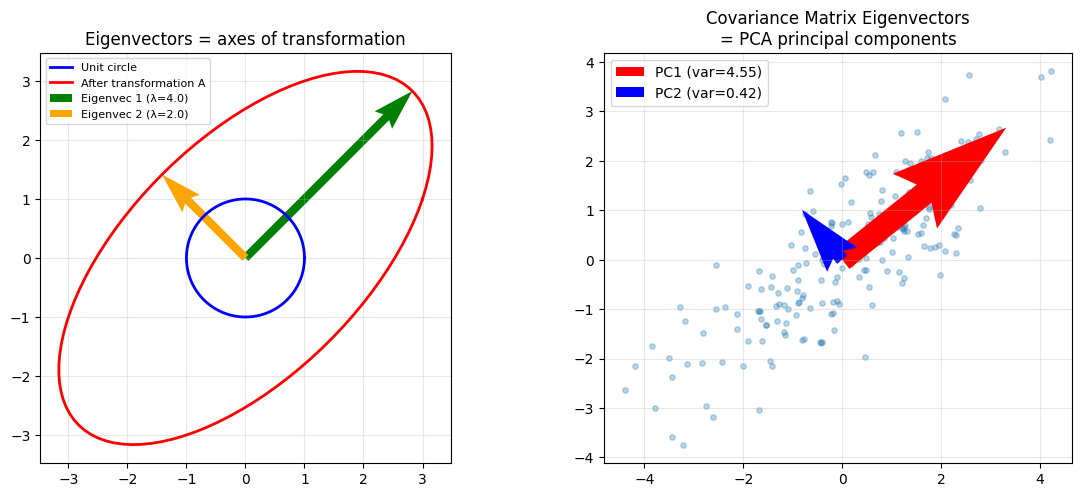

In [7]:
A = np.array([[3, 1],
              [1, 3]])

eigvals, eigvecs = np.linalg.eig(A)
print("Matrix A:")
print(A)
print(f"\nEigenvalues:  {eigvals}")
print(f"Eigenvectors:\n{eigvecs}")

# Verify: A @ v = λ * v
for i in range(len(eigvals)):
    v = eigvecs[:, i]
    Av = A @ v
    lv = eigvals[i] * v
    print(f"\nEigenvector {i+1}: {v.round(4)}")
    print(f"  A @ v  = {Av.round(4)}")
    print(f"  λ * v  = {lv.round(4)}")
    print(f"  Match: {np.allclose(Av, lv)}")

# Visualize: eigenvectors as the "natural axes" of the matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])
ellipse = A @ circle  # transform the circle

axes[0].plot(circle[0], circle[1], 'b-', label='Unit circle', lw=2)
axes[0].plot(ellipse[0], ellipse[1], 'r-', label='After transformation A', lw=2)
for i in range(2):
    v = eigvecs[:, i] * eigvals[i]
    axes[0].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                  color=['green','orange'][i], width=0.02,
                  label=f'Eigenvec {i+1} (λ={eigvals[i]:.1f})')
axes[0].set_title('Eigenvectors = axes of transformation')
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)

# Covariance matrix eigenvectors = PCA directions
data = np.random.multivariate_normal([0,0], [[3,2],[2,2]], 200)
cov = np.cov(data.T)
evals, evecs = np.linalg.eig(cov)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]

axes[1].scatter(data[:,0], data[:,1], alpha=0.3, s=15)
for i in range(2):
    v = evecs[:,i] * np.sqrt(evals[i]) * 2
    axes[1].quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
                  color=['red','blue'][i], width=0.05,
                  label=f'PC{i+1} (var={evals[i]:.2f})')
axes[1].set_title('Covariance Matrix Eigenvectors\n= PCA principal components')
axes[1].set_aspect('equal')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. SVD — Singular Value Decomposition

SVD breaks any matrix A into three matrices:

$$A = U \Sigma V^T$$

- `U` — left singular vectors (output space directions)
- `Σ` — singular values (importance/strength of each component)
- `Vᵀ` — right singular vectors (input space directions)

**Singular values ranked from largest to smallest** — the first few capture most of the information.  
Truncating to top-k gives the **best possible low-rank approximation** of A.

| Application | What SVD does |
|---|---|
| **Image compression** | Keep top-k singular values, discard rest |
| **Recommender systems** | Matrix factorization of user-item ratings |
| **LSA (NLP)** | Finds latent topics in text |
| **PCA** | SVD of centered data = PCA |
| **Pseudoinverse** | Solve overdetermined systems |

Original image shape: (427, 640)
U shape:  (427, 427)
S shape:  (427,)  (singular values)
Vt shape: (427, 640)

Top 5 singular values: [81959.1 14207.5 11463.3  6148.   5010.6]
Total singular values:  427

Components needed for:
  50% variance: 1 (of 427)
  90% variance: 1
  99% variance: 62


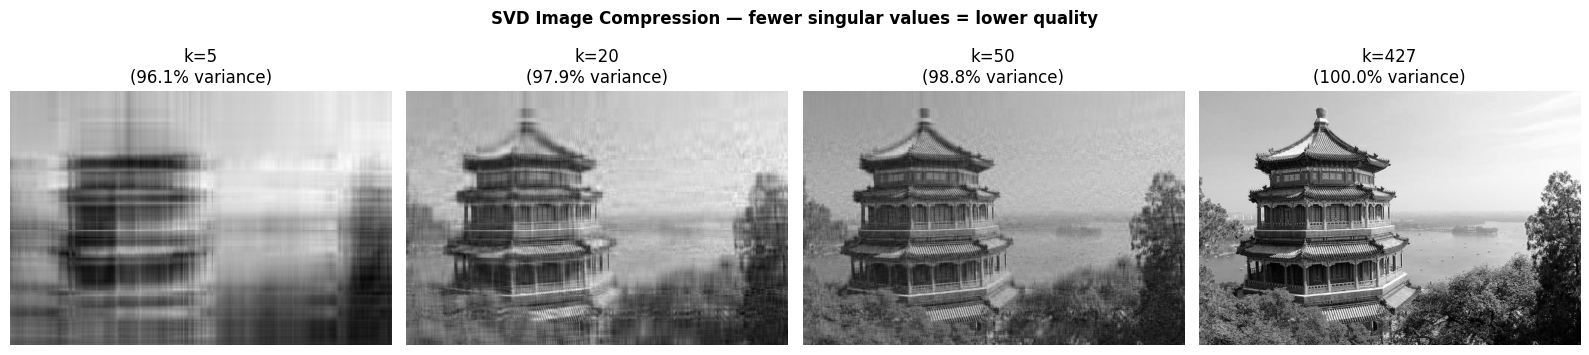

In [8]:
# SVD on a real example — image compression
from sklearn.datasets import load_sample_image
import warnings
warnings.filterwarnings('ignore')

try:
    china = load_sample_image("china.jpg")
    img = china[:,:,0].astype(float)  # use one color channel
except(FileNotFoundError, OSError, ImportError):
    # fallback if sklearn image not available
    img = np.random.rand(200, 300) * 255

U, S, Vt = np.linalg.svd(img, full_matrices=False)

print(f"Original image shape: {img.shape}")
print(f"U shape:  {U.shape}")
print(f"S shape:  {S.shape}  (singular values)")
print(f"Vt shape: {Vt.shape}")
print(f"\nTop 5 singular values: {S[:5].round(1)}")
print(f"Total singular values:  {len(S)}")

# Variance explained by top-k components
variance_explained = np.cumsum(S**2) / np.sum(S**2)
k50  = np.searchsorted(variance_explained, 0.50) + 1
k90  = np.searchsorted(variance_explained, 0.90) + 1
k99  = np.searchsorted(variance_explained, 0.99) + 1
print("\nComponents needed for:")
print(f"  50% variance: {k50} (of {len(S)})")
print(f"  90% variance: {k90}")
print(f"  99% variance: {k99}")

# Reconstruct with different k values
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ks = [5, 20, 50, len(S)]
for ax, k in zip(axes, ks):
    reconstructed = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    var = variance_explained[k-1] * 100
    ax.imshow(reconstructed, cmap='gray')
    ax.set_title(f'k={k}\n({var:.1f}% variance)')
    ax.axis('off')

plt.suptitle('SVD Image Compression — fewer singular values = lower quality', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Linear Algebra in Neural Networks

A neural network is a sequence of linear transformations + non-linearities:

```
Layer 1:  z₁ = W₁ @ x + b₁     (matrix multiply)
Activate: a₁ = ReLU(z₁)         (non-linearity)
Layer 2:  z₂ = W₂ @ a₁ + b₂    (matrix multiply)
Output:   ŷ  = softmax(z₂)      (normalize to probabilities)
```

**Everything is matrix multiplication.**  
The GPU's job is to do billions of these matrix multiplications extremely fast.

=== Neural Network Shape Flow ===
Input X:         (32, 784)    (batch × features)
After W1 (z1):   (32, 256)   (batch × hidden1)
After ReLU (a1): (32, 256)   (batch × hidden1)
After W2 (z2):   (32, 128)  (batch × hidden2)
After W3 (z3):   (32, 10)    (batch × classes)
After softmax:   (32, 10)    (batch × probabilities)

Total parameters: 235,146
That's 235,146 numbers the network needs to learn


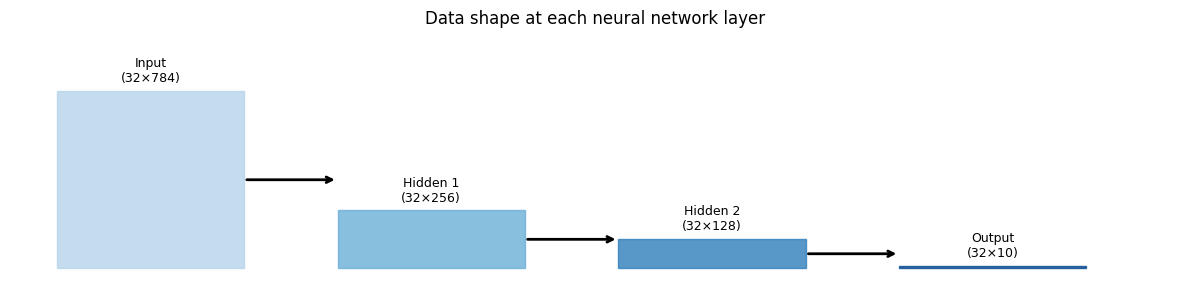

In [9]:
from matplotlib.patches import Rectangle

# A simple 3-layer network — shapes at each step
np.random.seed(0)
batch_size = 32
n_features = 784   # e.g., 28x28 MNIST image
n_hidden1  = 256
n_hidden2  = 128
n_classes  = 10

# Weight matrices
W1 = np.random.randn(n_features, n_hidden1) * 0.01  # Xavier-like init
W2 = np.random.randn(n_hidden1,  n_hidden2) * 0.01
W3 = np.random.randn(n_hidden2,  n_classes) * 0.01

b1 = np.zeros(n_hidden1)
b2 = np.zeros(n_hidden2)
b3 = np.zeros(n_classes)

# Input batch
X = np.random.randn(batch_size, n_features)

# Forward pass — all matrix multiplications
z1 = X @ W1 + b1
a1 = np.maximum(0, z1)    # ReLU

z2 = a1 @ W2 + b2
a2 = np.maximum(0, z2)    # ReLU

z3 = a2 @ W3 + b3
exp_z = np.exp(z3 - z3.max(axis=1, keepdims=True))
y_hat = exp_z / exp_z.sum(axis=1, keepdims=True)  # Softmax

print("=== Neural Network Shape Flow ===")
print(f"Input X:         {X.shape}    (batch × features)")
print(f"After W1 (z1):   {z1.shape}   (batch × hidden1)")
print(f"After ReLU (a1): {a1.shape}   (batch × hidden1)")
print(f"After W2 (z2):   {z2.shape}  (batch × hidden2)")
print(f"After W3 (z3):   {z3.shape}    (batch × classes)")
print(f"After softmax:   {y_hat.shape}    (batch × probabilities)")

# Count parameters
params = sum([W.size for W in [W1, W2, W3]] + [b.size for b in [b1, b2, b3]])
print(f"\nTotal parameters: {params:,}")
print(f"That's {params:,} numbers the network needs to learn")

# Visualize shape flow
shapes = [(batch_size, n_features), (batch_size, n_hidden1),
          (batch_size, n_hidden2), (batch_size, n_classes)]
labels = ['Input\n(32×784)', 'Hidden 1\n(32×256)', 'Hidden 2\n(32×128)', 'Output\n(32×10)']

fig, ax = plt.subplots(figsize=(12, 3))
for i, (shape, label) in enumerate(zip(shapes, labels)):
    rect = Rectangle((i*3, 0), 2, shape[1]/784*3, color=plt.get_cmap("Blues")(0.3+i*0.2), alpha=0.8)
    ax.add_patch(rect)
    ax.text(i*3+1, shape[1]/784*3+0.1, label, ha='center', va='bottom', fontsize=9)
    if i < len(shapes)-1:
        ax.annotate('', xy=((i+1)*3, shape[1]/784*1.5),
                    xytext=(i*3+2, shape[1]/784*1.5),
                    arrowprops=dict(arrowstyle='->', lw=2))
ax.set_xlim(-0.5, 12)
ax.set_ylim(-0.2, 4)
ax.set_title('Data shape at each neural network layer')
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 9. Linear Algebra in Transformers

Transformers (GPT, BERT, LLaMA) are built almost entirely from linear algebra.

### The Attention Mechanism:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- `Q` (Query) — "what am I looking for?"
- `K` (Key)   — "what do I contain?"
- `V` (Value) — "what do I give you?"

`QKᵀ` is a matrix of dot products — each query attending to each key.  
The result is a weighted sum of value vectors.

=== Transformer Attention Shapes ===
Input X (tokens):     (5, 8)  (seq_len × d_model)
Q, K, V projections:  (5, 8)  each
Attention weights:    (5, 5)  (seq_len × seq_len)
Output:               (5, 8)  (seq_len × d_model)


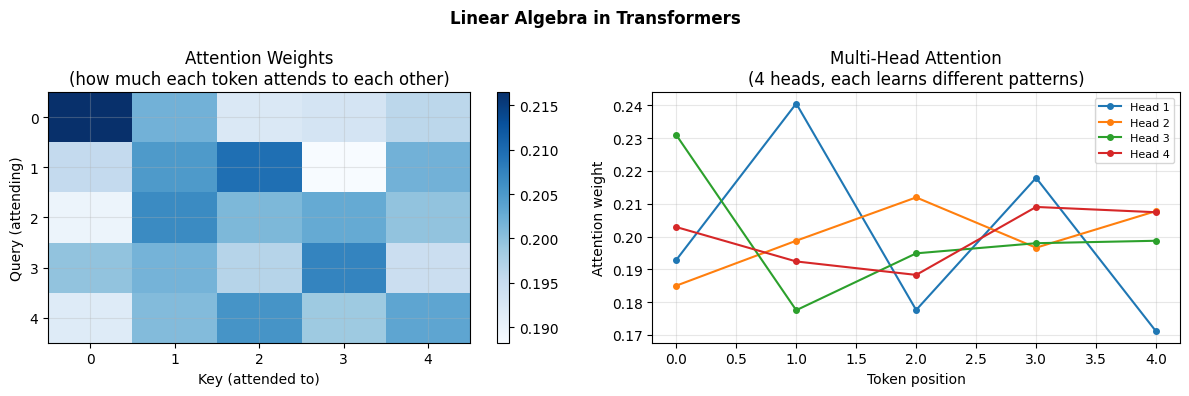


Key insight: The entire transformer forward pass is matrix multiplications + softmax.
GPT-4 does this with matrices of shape (vocab=100k, d_model=12288).


In [10]:
def softmax_rows(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)   # (seq_len, seq_len)
    weights = softmax_rows(scores)      # attention weights
    output = weights @ V               # weighted sum of values
    return output, weights

# Example: processing a sentence "The cat sat"
# Each word becomes a vector (embedding), then Q, K, V projections
np.random.seed(1)
seq_len = 5    # 5 tokens
d_model = 8   # embedding size

# In real transformers, Q,K,V are linear projections of the input
X = np.random.randn(seq_len, d_model)  # token embeddings
Wq = np.random.randn(d_model, d_model) * 0.1
Wk = np.random.randn(d_model, d_model) * 0.1
Wv = np.random.randn(d_model, d_model) * 0.1

Q = X @ Wq
K = X @ Wk
V = X @ Wv

output, attn_weights = attention(Q, K, V)

print("=== Transformer Attention Shapes ===")
print(f"Input X (tokens):     {X.shape}  (seq_len × d_model)")
print(f"Q, K, V projections:  {Q.shape}  each")
print(f"Attention weights:    {attn_weights.shape}  (seq_len × seq_len)")
print(f"Output:               {output.shape}  (seq_len × d_model)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Attention weight matrix
im = axes[0].imshow(attn_weights, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=axes[0])
axes[0].set_title('Attention Weights\n(how much each token attends to each other)')
axes[0].set_xlabel('Key (attended to)')
axes[0].set_ylabel('Query (attending)')

# Multi-head attention — run attention h times in parallel
n_heads = 4
d_head = d_model // n_heads
all_weights = []
for h in range(n_heads):
    Wq_h = np.random.randn(d_model, d_head) * 0.1
    Wk_h = np.random.randn(d_model, d_head) * 0.1
    Wv_h = np.random.randn(d_model, d_head) * 0.1
    _, w = attention(X @ Wq_h, X @ Wk_h, X @ Wv_h)
    all_weights.append(w)

for i, w in enumerate(all_weights):
    axes[1].plot(w[0], label=f'Head {i+1}', marker='o', ms=4)
axes[1].set_title('Multi-Head Attention\n(4 heads, each learns different patterns)')
axes[1].set_xlabel('Token position')
axes[1].set_ylabel('Attention weight')
axes[1].legend(fontsize=8)

plt.suptitle('Linear Algebra in Transformers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey insight: The entire transformer forward pass is matrix multiplications + softmax.")
print("GPT-4 does this with matrices of shape (vocab=100k, d_model=12288).")

---
## 10. Linear Algebra in Generative AI

### Latent Space (VAE, Diffusion, GANs)
Generative models learn a **latent space** — a compressed vector space where similar things are close together.

```
Image (224×224×3 = 150k dims)  →  Encoder  →  z (128 dims)  →  Decoder  →  Image
```

The latent vector `z` is just a point in a high-dimensional vector space.  
**Arithmetic in latent space** gives meaningful transformations:

```
king - man + woman ≈ queen         (word embeddings)
smiling_face - neutral + sunglasses ≈ smiling_with_sunglasses  (image VAE)
```

### Diffusion Models
Add Gaussian noise step-by-step, then learn to reverse it.  
At every step: `x_t = √ᾱ_t · x₀ + √(1-ᾱ_t) · ε` — pure linear algebra.

king - man + woman = [0.9 0.9]
queen = [0.9 0.9]
Closest word: 'queen' (distance=0.0000)


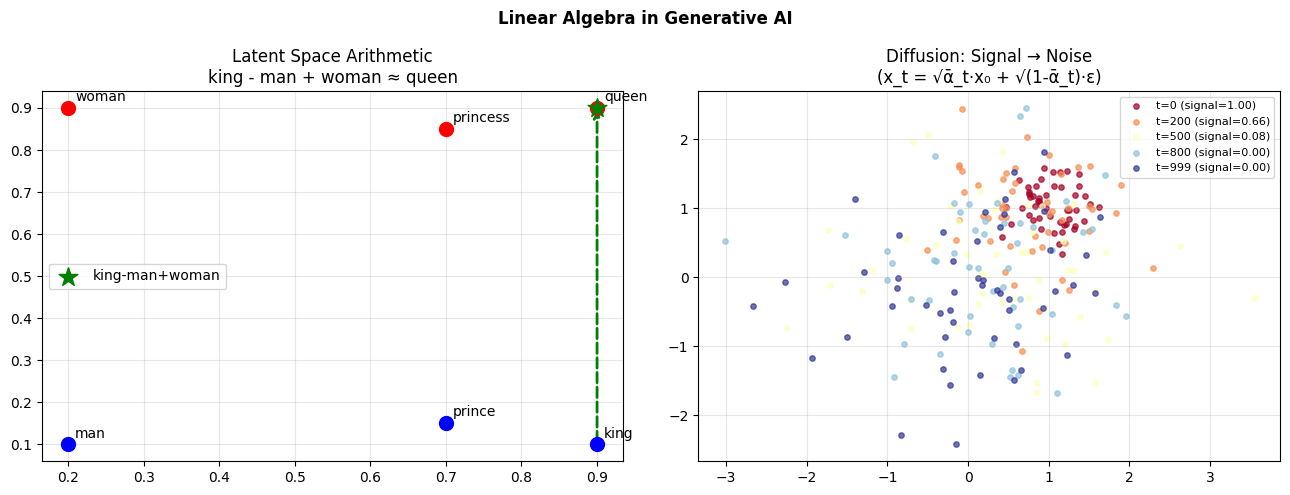

In [11]:
# Latent space arithmetic — word embedding analogy
# Simplified 2D embeddings for visualization
embeddings = {
    'king':   np.array([0.9, 0.1]),
    'queen':  np.array([0.9, 0.9]),
    'man':    np.array([0.2, 0.1]),
    'woman':  np.array([0.2, 0.9]),
    'prince': np.array([0.7, 0.15]),
    'princess': np.array([0.7, 0.85]),
}

# king - man + woman = ?
result = embeddings['king'] - embeddings['man'] + embeddings['woman']
print("king - man + woman =", result.round(3))
print("queen =", embeddings['queen'])

# Find closest word
dists = {word: np.linalg.norm(vec - result) for word, vec in embeddings.items()
        if word not in ['king', 'man', 'woman']}
closest = min(dists, key=lambda k: dists[k])
print(f"Closest word: '{closest}' (distance={dists[closest]:.4f})")

# Visualize latent space
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = {'king':'blue','queen':'red','man':'blue','woman':'red','prince':'blue','princess':'red'}
for word, vec in embeddings.items():
    ax.scatter(*vec, s=100, color=colors.get(word,'gray'), zorder=5)
    ax.annotate(word, vec, textcoords='offset points', xytext=(5,5), fontsize=10)

ax.annotate('', xy=result, xytext=embeddings['king'],
            arrowprops=dict(arrowstyle='->', color='green', lw=2, linestyle='--'))
ax.scatter(*result, s=200, color='green', marker='*', zorder=6, label='king-man+woman')
ax.set_title("Latent Space Arithmetic\nking - man + woman ≈ queen")
ax.legend()

# Diffusion noise schedule visualization
T = 1000
betas = np.linspace(1e-4, 0.02, T)
alpha_bars = np.cumprod(1 - betas)

x0 = np.random.randn(50, 2) * 0.3 + np.array([1, 1])  # original data cluster

timesteps = [0, 200, 500, 800, 999]
colors_t = plt.get_cmap("RdYlBu")(np.linspace(0, 1, len(timesteps)))
for t_idx, color in zip(timesteps, colors_t):
    ab = alpha_bars[t_idx]
    noise = np.random.randn(*x0.shape)
    x_t = np.sqrt(ab) * x0 + np.sqrt(1 - ab) * noise
    axes[1].scatter(x_t[:,0], x_t[:,1], s=15, color=color, alpha=0.7,
                    label=f't={t_idx} (signal={ab:.2f})')

axes[1].set_title('Diffusion: Signal → Noise\n(x_t = √ᾱ_t·x₀ + √(1-ᾱ_t)·ε)')
axes[1].legend(fontsize=8)

plt.suptitle('Linear Algebra in Generative AI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary — Linear Algebra Across the Stack

```
Classic ML
  └── Dot product: ŷ = wᵀx           (linear regression, logistic regression)
  └── Norms: ||w||                    (L1/L2 regularization)
  └── Eigenvalues: Σv = λv            (PCA)
  └── SVD: A = UΣVᵀ                  (dimensionality reduction)

Deep Learning
  └── Matrix multiply: z = Wx + b     (every layer)
  └── Batch processing: Z = XWᵀ       (GPU efficiency)
  └── Softmax: normalize(exp(z))      (output probabilities)

Transformers (GPT, BERT, LLaMA)
  └── Attention: softmax(QKᵀ/√dk)·V  (self-attention)
  └── Multi-head: run h attentions    (diverse pattern capture)
  └── Feed-forward: two matrix mults  (position-wise MLP)

Generative AI
  └── Latent vectors: z ~ N(μ, σ²)   (VAE)
  └── Latent arithmetic: king-man+woman=queen
  └── Diffusion: xₜ = √ᾱₜ·x₀ + √(1-ᾱₜ)·ε
```

| Operation | Formula | Where |
|---|---|---|
| Dot product | `aᵀb = Σ aᵢbᵢ` | Linear regression, attention scores |
| Matrix multiply | `Z = XW` | Every neural layer |
| Cosine similarity | `aᵀb / (||a||·||b||)` | Embeddings, RAG retrieval |
| L2 norm | `sqrt(Σ wᵢ²)` | Weight decay, regularization |
| Eigenvectors | `Av = λv` | PCA, spectral methods |
| SVD | `A = UΣVᵀ` | Compression, recommendations |
| Attention | `softmax(QKᵀ/√dk)V` | Transformers |

### What to learn next
- **Calculus** → how gradients flow through these matrix operations (backprop)
- **PCA notebook** → eigenvalues applied to real data
- **Neural network notebook** → all these shapes in a real PyTorch model